# Бейзлайн: dummy и логистическая регрессия

Сначала самый тупой бейзлайн (most_frequent), потом LR с GridSearch по C.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from category_encoders import TargetEncoder

from src.features import NUMERIC_COLS, LOW_CARD_CAT, HIGH_CARD_CAT

In [2]:
split = joblib.load('../models/_split.pkl')
X_train, X_test = split['X_train'], split['X_test']
y_train, y_test = split['y_train'], split['y_test']
X_train.shape

(69576, 37)

### Dummy

In [3]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
pred = dummy.predict(X_test)
# у most_frequent predict_proba будет выдавать константу, ROC-AUC ровно 0.5
print('accuracy:', (pred == y_test).mean())
print('ROC-AUC:', roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))

accuracy: 0.7269173278141888
ROC-AUC: 0.5


### Логистическая регрессия

In [4]:
pre = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), LOW_CARD_CAT),
    ('te', TargetEncoder(cols=HIGH_CARD_CAT, smoothing=10), HIGH_CARD_CAT),
])

pipe = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=2000, solver='lbfgs')),
])

In [5]:
grid = GridSearchCV(
    pipe,
    param_grid={'clf__C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print('best C:', grid.best_params_)
print('best CV ROC-AUC:', round(grid.best_score_, 4))

best C: {'clf__C': 10}
best CV ROC-AUC: 0.8418


In [6]:
best = grid.best_estimator_
proba = best.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print('test ROC-AUC:', round(roc_auc_score(y_test, proba), 4))
print('test F1 (cancel):', round(f1_score(y_test, pred), 4))
print()
print(classification_report(y_test, pred, target_names=['stay','cancel']))

test ROC-AUC: 0.8388
test F1 (cancel): 0.5551

              precision    recall  f1-score   support

        stay       0.82      0.92      0.87     12644
      cancel       0.68      0.47      0.56      4750

    accuracy                           0.80     17394
   macro avg       0.75      0.69      0.71     17394
weighted avg       0.78      0.80      0.78     17394



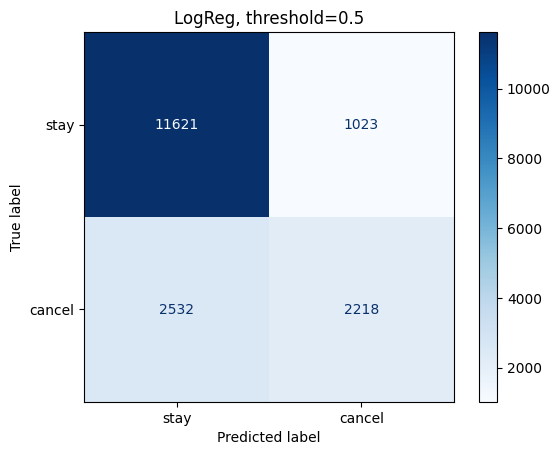

In [7]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['stay','cancel']).plot(cmap='Blues')
plt.title('LogReg, threshold=0.5')
plt.show()

### Интерпретация коэффициентов

Логрегрессия - линейная, можно посмотреть какие фичи тянут в сторону отмены.

In [8]:
clf = best.named_steps['clf']
pre_fitted = best.named_steps['pre']
feat_names = (NUMERIC_COLS
              + list(pre_fitted.named_transformers_['cat'].get_feature_names_out(LOW_CARD_CAT))
              + HIGH_CARD_CAT)
coefs = pd.Series(clf.coef_[0], index=feat_names).sort_values(key=abs, ascending=False)
coefs.head(15)

country                         8.043371
required_car_parking_spaces    -3.844364
deposit_type_No Deposit        -2.017154
deposit_type_Non Refund         1.497625
market_segment_Offline TA/TO   -1.152905
distribution_channel_GDS       -1.026274
room_changed                   -0.795938
deposit_type_Refundable        -0.770408
customer_type_Group            -0.730324
hotel_City Hotel               -0.704410
reserved_room_type_C           -0.629725
assigned_room_type_A           -0.590769
hotel_Resort Hotel             -0.585528
total_of_special_requests      -0.559744
season_summer                  -0.556169
dtype: float64

Топ-веса идут в стандартную сторону: `deposit_type_Non Refund`, `previous_cancellations`, `lead_time` - увеличивают риск. `total_of_special_requests`, `required_car_parking_spaces`, `booking_changes` - уменьшают. Логично: если человек делает спецзапросы и бронирует парковку, значит реально едет.

Сохраним модель чтобы потом сравнить.

In [9]:
joblib.dump(best, '../models/_logreg.pkl')
print('saved')

saved
